# 02 - Mainnet CPMM

Raydium CPMM analysis for snapshot-derived CPMM scenarios and the historical CPMM decoding pipeline.

Inputs:
- `results/real_pool_comparison.csv`
- `results/historical_cpmm_swaps_status.csv`
- `results/historical_cpmm_pipeline_summary.csv`
- `results/historical_cpmm_decoded.csv`
- `results/historical_cpmm_candidates.csv`


## Data readiness


In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "helpers").exists():
        sys.path.insert(0, str(candidate))
        break
    if (candidate / "notebooks" / "helpers").exists():
        sys.path.insert(0, str(candidate / "notebooks"))
        break

import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from helpers import (
    blocker_table,
    data_readiness,
    find_repo_root,
    historical_candidate_summary,
    historical_pipeline_funnel,
    historical_rejection_pareto,
    historical_slippage_summary,
    historical_takeaway_lines,
    historical_top_candidates,
    hypothesis_scorecard,
    load_inputs,
    plot_profit_distribution,
    plot_rejection_pareto,
    plot_size_vs_profit,
    plot_slippage_feasibility,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

ROOT = find_repo_root()
inputs = load_inputs(ROOT)

comparison = inputs["frames"]["real_pool_comparison"]
historical = inputs["frames"]["historical_cpmm_candidates"]
historical_frames = {
    name: inputs["frames"][name]
    for name in [
        "historical_cpmm_swaps_status",
        "historical_cpmm_pipeline_summary",
        "historical_cpmm_decoded",
        "historical_cpmm_candidates",
    ]
}
funnel = historical_pipeline_funnel(historical_frames)
rejections = historical_rejection_pareto(historical_frames)

readiness_names = ["real_pool_comparison", *historical_frames.keys()]
display(data_readiness(ROOT, inputs, readiness_names))
if comparison.attrs.get("legacy_schema", False):
    display(Markdown("> CPMM comparison CSV is old-schema. Regenerate before final thesis numbers."))


,dataset,file,rows,columns,ready_for_final_numbers,note
0,real_pool_comparison,results/real_pool_comparison.csv,32,36,True,ok
1,historical_cpmm_swaps_status,results/historical_cpmm_swaps_status.csv,18191,16,True,ok
2,historical_cpmm_pipeline_summary,results/historical_cpmm_pipeline_summary.csv,6,7,True,ok
3,historical_cpmm_decoded,results/historical_cpmm_decoded.csv,3515,18,True,ok
4,historical_cpmm_candidates,results/historical_cpmm_candidates.csv,3515,49,False,legacy schema: regenerate CSV


## Snapshot CPMM scorecard


In [2]:
if comparison.empty:
    display(Markdown("Generate `results/real_pool_comparison.csv` first."))
else:
    display(hypothesis_scorecard(comparison))
    display(blocker_table(comparison))


,question,metric,value
0,Czy atak zarabia przed slippage filter?,profitable rows,50.0%
1,Czy ofiara nie revertuje?,feasible rows,75.0%
2,Czy atak jest ekonomicznie realizowalny?,profitable and feasible rows,25.0%
3,Typowy wynik attackera,median net profit,"8,272,240"
4,Typowa strata ofiary w udanych przypadkach,median victim loss bps,51


,blocker,rows,share,median_net_profit,median_victim_loss_bps
0,not_profitable,16,0.50,-3.598298e+06,2.5
1,realized,8,0.25,1.904890e+07,51.0
2,victim_would_revert,8,0.25,4.699981e+09,478.0


## Historical pipeline funnel


In [3]:
display(funnel)


,stage,rows
0,collected_signatures,18191
1,decoded_swaps,3515
2,evaluated_rows,3515
3,analysis_candidates,3509
4,excluded_below_threshold,2839
5,rejected_rows,14676


## Rejection Pareto


,reason,rows,share,cumulative_share
0,no_cpmm_swap,8097,0.551717,0.551717
1,tx_failed,6440,0.438812,0.990529
2,unsupported_swap_instruction,139,0.009471,1.000000


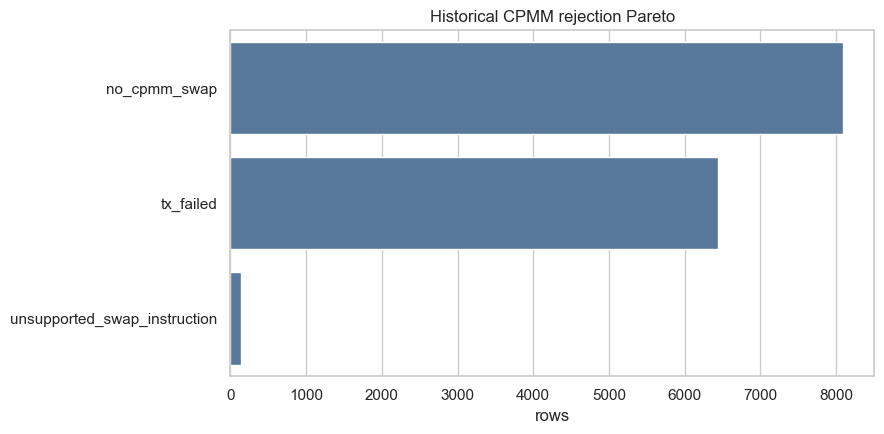

In [4]:
if rejections.empty:
    display(Markdown("No historical CPMM rejection reasons available yet."))
else:
    display(rejections)
    fig = plot_rejection_pareto(rejections)
    if fig is None:
        display(Markdown("Rejection Pareto plot omitted because the data is flat or single-point."))


## Historical candidate summary


In [5]:
display(historical_candidate_summary(historical))


,metric,value
0,evaluated rows,3515
1,excluded below threshold,6
2,analysis candidates,3509
3,profitable rate,0.6%
4,feasible rate,0.6%
5,realized rate,0.6%
6,median net profit,0.0
7,max net profit,41771518831866
8,positive profit rows,22


## Profit distribution


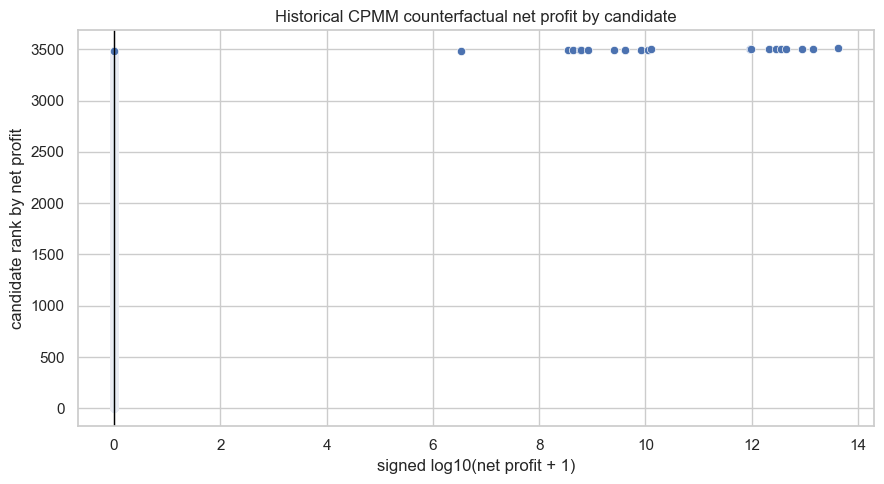

In [6]:
fig = plot_profit_distribution(historical)
if fig is None:
    display(Markdown("Profit distribution plot omitted because candidate profit data is missing, flat, or single-point."))


## Size vs profit


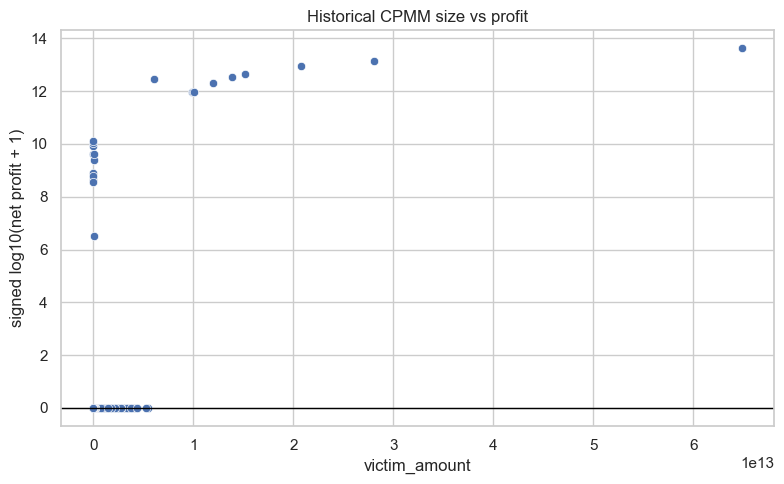

In [7]:
fig = plot_size_vs_profit(historical)
if fig is None:
    display(Markdown("Size-vs-profit plot omitted because candidate size/profit data is missing, flat, or single-point."))


## Slippage feasibility


In [8]:
slippage_summary = historical_slippage_summary(historical)
if slippage_summary.empty:
    display(Markdown("No historical CPMM slippage feasibility columns available yet."))
else:
    display(slippage_summary)
fig = plot_slippage_feasibility(historical)
if fig is None:
    display(Markdown("Slippage feasibility plot omitted because the data is missing, flat, or single-point."))


No historical CPMM slippage feasibility columns available yet.

Slippage feasibility plot omitted because the data is missing, flat, or single-point.

## Top-N candidates


In [9]:
top_candidates = historical_top_candidates(historical, limit=10)
if top_candidates.empty:
    display(Markdown("No ranked historical CPMM candidates yet."))
else:
    display(top_candidates)


,signature,slot,pool_label,victim_amount,amount_in,frontrun_amount,victim_extra_slippage_bps,attacker_net_profit
374,3sgbBJVzQqjK9n1MHrJdQfrZBxG9Kq8N1hpGEatKgLe4cX...,418855299,wsol_surge,64811166855053,64811166855053,2721111180631015,7467,41771518831866
462,2q757JUr8UFPH1z3tYSyUdNxfymr4SY7CUR1X9mkCQeR2o...,418851441,wsol_surge,28082659919038,28082659919038,2678346418388305,7483,14323416993660
615,4TPwpkqRi39NSY8Cx1hpWxpbv6GEZA6R4YAMfcybLpE7Bc...,418844547,wsol_surge,20753960830000,20753960830000,2705805075602564,7487,8763478582183
19,4mtWHafhD9EYf9ETLkno2zzLWX9jY6atLBC3RSas87iHLi...,418872900,wsol_surge,15136290066401,15136290066401,2738301050299401,7489,4474714850920
460,5De7t3b7vMq3727m8Na4SfdJVR9MHj91F5ZKjWPr4xPaUL...,418851471,wsol_surge,13821956935991,13821956935991,2705979309739343,7490,3571521623179
3473,25hn6C7ynSTPBsBi6oDzD4xJCaS1DGdzAgiKQwt1XwCxkd...,418854357,wsol_debt,6028246007515,6028246007515,104429095902258,7411,2896258753434
15,V7ppUDRGJ91ZLMv2Kh6Vasf9VBjUAAN7KATSSAB4eriTk1...,418872984,wsol_surge,11950147528024,11950147528024,2015028671251223,6658,2127179323216
1910,MtiHNh1E74yiiDZZpY63XdANm5f5ZTap9hiLqGvNE3JqU1...,418778650,wsol_surge,10041154685996,10041154685996,1247644931084842,5252,970933437839
1803,3JAugRB2zTnurv1pzvAbjVrCxgLYD5aFzkzNTS6Uw15H2a...,418783713,wsol_surge,9953463622073,9953463622073,1228364727212267,5223,949461496886
975,4PtSLxTQbqycdrxmC7HzmTMTBGYxsGcU6p4HJRGJrnhD2K...,418825523,wsol_surge,9859651454906,9859651454906,1213667583008353,5212,935714019399


## Thesis-ready takeaways


In [10]:
lines = historical_takeaway_lines(comparison, historical, funnel, rejections)
display(Markdown("\n".join(lines) if lines else "No CPMM conclusions yet."))


- Snapshot-derived CPMM realized rate: `25.0%` over `32` rows.
- Historical CPMM evaluated `3515` row(s); `3509` passed the analysis threshold.
- Main historical rejection reason: `no_cpmm_swap` (`55.2%` of rejected rows).
- Historical CPMM analysis candidates: `3509` rows, median net profit `0`.